In [43]:
import pandas as pd
import numpy as np
import seaborn as sns

import plotting_utils

sns.set_style('ticks')
import matplotlib.pyplot as plt
import os

In [24]:
# Load results
#foc_results_df = pd.read_csv(os.path.join(focality_path, 'focality_neurons_results.csv'))
focality_path=r"M:\analysis\Axel_Bisi\combined_results\glm_atlas_cmap\focality_analysis"
foc_results_df = pd.read_csv(os.path.join(focality_path, 'focality_results_neurons.csv'))

In [25]:
foc_results_df.head()

,model_name,reward_group,observed_focality,bootstrap_mean,bootstrap_se,ci_lower,ci_upper,n_mice,n_neurons,n_areas,difference,p_value,cohens_d,p_fdr
0,block_perf_type,R+,0.023999,0.025083,0.000619,0.023870,0.026296,33,8763,47,0.000172,0.7479,0.284611,0.835900
1,block_perf_type,R-,0.023827,0.024946,0.000590,0.023790,0.026101,30,8748,47,0.000172,0.7479,0.284611,0.835900
2,last_false_alarm,R+,0.024614,0.026696,0.001344,0.024061,0.029330,33,8763,47,-0.000951,0.2425,-0.713324,0.788125
3,last_false_alarm,R-,0.025564,0.027831,0.001321,0.025241,0.030420,30,8748,47,-0.000951,0.2425,-0.713324,0.788125
4,last_reward,R+,0.024427,0.025797,0.000767,0.024294,0.027300,33,8763,47,-0.000198,0.8002,-0.258086,0.835900


C:\Users\bisi\AppData\Local\Temp\ipykernel_17632\876111338.py:40: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=foc_results_df,
C:\Users\bisi\AppData\Local\Temp\ipykernel_17632\876111338.py:40: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.pointplot(data=foc_results_df,
C:\Users\bisi\AppData\Local\Temp\ipykernel_17632\876111338.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([model_name_dict.get(label.get_text(), label.get_text()) for label in ax.get_xticklabels()], rotation=30, ha='right')


[[0.0012458350447515018], [0.0012458350447514983]]
[[0.0012132664754270009], [0.0012132664754269003]]
[[0.0012089308900775989], [0.0012089308900775017]]
[[0.0012320828321486996], [0.0012320828321486996]]
[[0.0034242115535320986], [0.0034242115535320014]]
[[0.006158836446108498], [0.006158836446108602]]
[[0.0005714480676379009], [0.0005714480676379009]]
[[0.000687565341795298], [0.0006875653417953015]]
[[0.0014372665713709987], [0.0014372665713709015]]
[[0.002384011696278103], [0.0023840116962780995]]
[[0.0039565569237591], [0.003956556923758996]]
[[0.0026738855807450987], [0.002673885580745102]]
[[0.0012130687728322993], [0.0012130687728322993]]
[[0.0011559655896576995], [0.0011559655896576995]]
[[0.0011048814172143033], [0.0011048814172142998]]
[[0.0009114519583251005], [0.0009114519583251005]]
[[0.0013120585167544982], [0.0013120585167545017]]
[[0.001747234660901202], [0.0017472346609012993]]


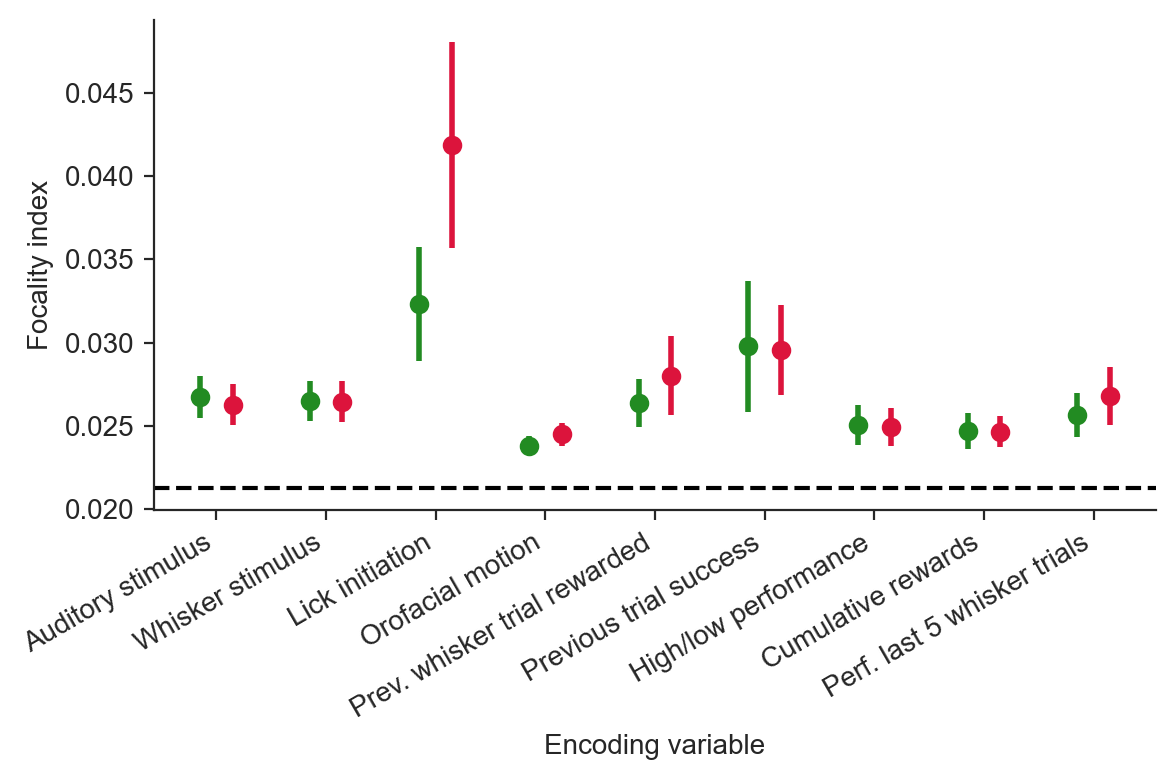

In [44]:

uniform_level = 1 / 47
fig, ax = plt.subplots(figsize=(6,4), dpi=200)
plotting_utils.remove_top_right_frame(ax)

# Rename x labels
model_name_dict = {
    'auditory_encoding': 'Auditory stimulus',
    'whisker_encoding': 'Whisker stimulus',
    'jaw_onset_encoding': 'Lick initiation',
    'motor_encoding': 'Orofacial motion',
    #'last_reward': 'Prev. trial rewarded',
    'last_whisker_reward': 'Prev. whisker trial rewarded',
    #'last_false_alarm': 'Prev. trial false alarm',
    'prev_success': 'Previous trial success',
    'block_perf_type': 'High/low performance',
    #'prop_past_whisker_reward':'Prop. past whisker rewards',
    #'session_progress_encoding':'Trial index',
    'sum_rewards':'Cumulative rewards',
    'whisker_reward_rate_5':'Perf. last 5 whisker trials',
}
order = [
    'auditory_encoding',
    'whisker_encoding',
    'jaw_onset_encoding',
    'motor_encoding',
    #'last_reward',
    'last_whisker_reward',
    #'last_false_alarm',
    'prev_success',
    'block_perf_type',
    #'prop_past_whisker_reward',
    #'session_progress_encoding',
    'sum_rewards',
    'whisker_reward_rate_5',
]
# Reorder based on order
foc_results_df = foc_results_df.set_index('model_name').loc[order].reset_index()

foc_results_df = foc_results_df[foc_results_df.model_name.isin(model_name_dict.keys())]
sns.pointplot(data=foc_results_df,
              x='model_name',
              order=order,
              y='bootstrap_mean',
              hue='reward_group',
              hue_order=['R+', 'R-'],
              markersize=5,
              dodge=0.3,
              join=False,
              capsize=0.0,
              errwidth=1.5,
              palette=['forestgreen','crimson'],
              legend=False,
              ax=ax)
# add errorbars using ci_lower and ci_upper
for i, row in foc_results_df.iterrows():
    x = foc_results_df['model_name'].unique().tolist().index(row['model_name'])
    if row['reward_group'] == 'R+':
        x -= 0.15
        color = 'forestgreen'
    else:
        x += 0.15
        color = 'crimson'
    yerr = [[row['bootstrap_mean'] - row['ci_lower']], [row['ci_upper'] - row['bootstrap_mean']]]
    print(yerr)
    ax.errorbar(x,
                row['bootstrap_mean'],
                yerr=yerr,
                fmt='none',
                c=color,
                capsize=0,
                elinewidth=2, zorder=-1)

ax.axhline(uniform_level, color='k', linestyle='--', label='Uniform distribution')
ax.set_ylabel('Focality index')
ax.set_xlabel('Encoding variable')


ax.set_xticklabels([model_name_dict.get(label.get_text(), label.get_text()) for label in ax.get_xticklabels()], rotation=30, ha='right')
ax.set_ylabel('Focality index')
ax.set_xlabel('Encoding variable')
plt.tight_layout()

figname = 'glm_focality_index_pointplot'
# Save
fig_path = os.path.join(focality_path, figname)
#plt.savefig(fig_path, dpi=400, bbox_inches='tight')
plotting_utils.save_figure_with_options(fig,
                                        ['png','pdf','svg'],
                                        figname,
                                        focality_path,
                                        dark_background=False
                                        )
